# Modeling

In [1]:
import os, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
#For SMOTE
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
# 核心：引入 ImbPipeline 确保交叉验证时不发生数据泄露
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

In [4]:
df = pd.read_csv("BankChurners.csv")
#填入你精选的 Top 10 特征
top_10_features = ["Customer_Age","Gender","Total_Trans_Amt","Education_Level",
                  "Marital_Status","Income_Category","Card_Category","Credit_Limit",
                  "Avg_Utilization_Ratio","Months_Inactive_12_mon"]

X = df[top_10_features]
df["target"] = df["Attrition_Flag"].apply(lambda x: 1 if x == "Attrited Customer" else 0)
y = df["target"]

# 2. 先切分！把测试集锁起来
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. 动态获取类别特征的索引 (SMOTENC 必须)
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

## Logistic Regression

In [5]:
import os, json, joblib
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
# 确保引入了 pipeline 组件
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# 1. 组装 Logistic Regression 的防泄露流水线
pipeline_lr = ImbPipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('smote', SMOTENC(categorical_features=cat_indices, random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', LogisticRegression(class_weight="balanced", random_state=42))
])

# 2. 网格搜索 (参数名加上 model__ 前缀)
grid_para_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"],
    "model__max_iter": [1000, 5000]
}

grid_search_lr = GridSearchCV(
    estimator=pipeline_lr, 
    param_grid=grid_para_lr, 
    cv=5, 
    scoring="roc_auc", 
    n_jobs=-1, 
    verbose=1
)

# 直接在未受污染的原始 X_train 上训练
print("开始训练 Logistic Regression (包含内部 SMOTE)...")
grid_search_lr.fit(X_train, y_train)

# 提取最佳模型
best_pipeline_lr = grid_search_lr.best_estimator_
print("===========Best Parameters from Grid Search (LR)===========")
print("Best Parameters:", grid_search_lr.best_params_)
print(f"Best CV ROC-AUC: {grid_search_lr.best_score_:.4f}")

# 3. 预测概率并寻找最佳阈值 (Threshold Tuning)
y_prob = best_pipeline_lr.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.0, 1.01, 0.01)
thresholds_results = []
for thresh in thresholds:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    thresholds_results.append({
        "threshold": thresh, 
        "accuracy": accuracy_score(y_test, y_pred_thresh),
        "precision": precision_score(y_test, y_pred_thresh, zero_division=0),
        "recall": recall_score(y_test, y_pred_thresh, zero_division=0),
        "f1": f1_score(y_test, y_pred_thresh, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob) # 对于同一组预测概率，AUC 是恒定的
    })

df_thresh = pd.DataFrame(thresholds_results)
best_thresh_row = df_thresh.loc[df_thresh["f1"].idxmax()]
best_threshold = best_thresh_row["threshold"]

print(f"\n===========最佳分类阈值 (Optimized for F1)===========")
print(f"Best Threshold: {best_threshold:.2f}")

# 4. 使用最佳阈值进行最终预测
y_pred = (y_prob >= best_threshold).astype(int)

# 安全处理 params 里的 Numpy 数据类型，防止 JSON 报错
safe_best_params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search_lr.best_params_.items()}

# 5. 组装评估指标
lr_metrics = {
    "model": "Logistic Regression",
    "best_params": safe_best_params,
    "best_threshold": float(best_threshold), # 记录下最佳阈值供前端参考
    "best_cv_roc_auc": float(grid_search_lr.best_score_),
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, zero_division=0)),
    "recall": float(recall_score(y_test, y_pred, zero_division=0)),
    "f1": float(f1_score(y_test, y_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, y_prob)),
    "confusion_matrix": confusion_matrix(y_test, y_pred).tolist(),
}

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=["Not Attrited", "Attrited"], digits=4, zero_division=0))

# 6. 组装 Grid Search 详细结果供前端展示
results_df = pd.DataFrame(grid_search_lr.cv_results_)[
    ["param_model__C", "param_model__solver", "param_model__max_iter", "mean_test_score"]
].copy()
results_df.columns = ["C", "Solver", "Max_Iter", "ROC-AUC"]

grid_results = {
    "best_params": safe_best_params,
    "best_score": float(grid_search_lr.best_score_),
    "all_results": json.loads(results_df.to_json(orient="records"))
}

# 7. 创建文件夹并保存最终文件
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# 核心：保存完整的 pipeline 和 features 列表！
joblib.dump({"pipeline": best_pipeline_lr, "features": top_10_features}, "models/lr_model.joblib")

with open("artifacts/lr_metrics.json", "w", encoding="utf-8") as f:
    json.dump(lr_metrics, f, indent=2)

with open("artifacts/lr_grid_results.json", "w", encoding="utf-8") as f:
    json.dump(grid_results, f, indent=2)

print("\nSaved: models/lr_model.joblib, artifacts/lr_metrics.json, artifacts/lr_grid_results.json")

开始训练 Logistic Regression (包含内部 SMOTE)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits
===========Best Parameters from Grid Search (LR)===========
Best Parameters: {'model__C': 0.1, 'model__max_iter': 1000, 'model__solver': 'liblinear'}
Best CV ROC-AUC: 0.7502

===========最佳分类阈值 (Optimized for F1)===========
Best Threshold: 0.70

Confusion Matrix:
 [[1260  441]
 [ 122  203]]

Classification Report:
               precision    recall  f1-score   support

Not Attrited     0.9117    0.7407    0.8174      1701
    Attrited     0.3152    0.6246    0.4190       325

    accuracy                         0.7221      2026
   macro avg     0.6135    0.6827    0.6182      2026
weighted avg     0.8160    0.7221    0.7535      2026


Saved: models/lr_model.joblib, artifacts/lr_metrics.json, artifacts/lr_grid_results.json


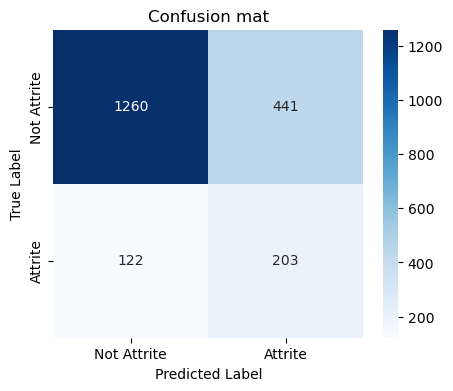

In [6]:
confusion_mat = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    confusion_mat,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not Attrite', 'Attrite'],
    yticklabels=['Not Attrite', 'Attrite']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion mat')
plt.show()

## SVM

In [7]:
from sklearn.svm import SVC
import os, json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

In [8]:
import os, json, joblib
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
# 确保引入了 pipeline 组件
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# 1. 组装 SVM 的防泄露流水线
pipeline_svm = ImbPipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('smote', SMOTENC(categorical_features=cat_indices, random_state=42)),
    ('scaler', MinMaxScaler()),
    # 注意：SVC 必须设置 probability=True 才能计算 ROC-AUC
    ('model', SVC(probability=True, class_weight="balanced", random_state=42))
])

# 2. 优化网格搜索参数 (分离 linear 和非线性核，避免浪费时间计算 linear 的 gamma)
grid_para_svm = [
    {"model__kernel": ["linear"], "model__C": [0.01, 0.1, 1, 10]},
    {"model__kernel": ["rbf", "poly"], "model__C": [0.01, 0.1, 1, 10], "model__gamma": ["scale", 0.01, 0.1]}
]

grid_search_svm = GridSearchCV(
    estimator=pipeline_svm,
    param_grid=grid_para_svm,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 直接在未受污染的原始 X_train 上训练
print("开始训练 SVM (包含内部 SMOTE，这可能需要一些时间)...")
grid_search_svm.fit(X_train, y_train)

# 提取最佳模型
best_pipeline_svm = grid_search_svm.best_estimator_
print("===========Best Parameters from Grid Search (SVM)===========")
print("  Params:", grid_search_svm.best_params_)
print(f"  Best CV ROC-AUC: {grid_search_svm.best_score_:.4f}")

# 3. 预测 (在原始 X_test 上测试)
svm_pred = best_pipeline_svm.predict(X_test)
svm_prob = best_pipeline_svm.predict_proba(X_test)[:, 1]

# 安全处理 params 里的 Numpy 数据类型，防止 JSON 报错
safe_best_params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search_svm.best_params_.items()}

# 4. 组装评估指标 (记得把 svm_metrics 里的 best_params 也换成 safe_best_params)
svm_metrics = {
    "model": "SVM",
    "best_params": safe_best_params, 
    "best_cv_roc_auc": float(grid_search_svm.best_score_),
    "accuracy": float(accuracy_score(y_test, svm_pred)),
    "precision": float(precision_score(y_test, svm_pred, zero_division=0)),
    "recall": float(recall_score(y_test, svm_pred, zero_division=0)),
    "f1": float(f1_score(y_test, svm_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, svm_prob)),
    "confusion_matrix": confusion_matrix(y_test, svm_pred).tolist(),
}

print("\nConfusion Matrix:\n", confusion_matrix(y_test, svm_pred))
print("\nClassification Report:\n", classification_report(y_test, svm_pred, target_names=["Not Attrited", "Attrited"], digits=4))

# 5. 组装 Grid Search 详细结果供前端展示
results_df = pd.DataFrame(grid_search_svm.cv_results_)[
    ["param_model__kernel", "param_model__C", "param_model__gamma", "mean_test_score"]
].copy()

# 将 NaN 填充为 "N/A" (因为 linear kernel 没有 gamma)
results_df.fillna("N/A", inplace=True)

# 修复了你原代码中的双层括号 Bug
results_df.columns = ["Kernel", "C", "Gamma", "ROC-AUC"]

grid_results = {
    "best_params": safe_best_params,
    "best_score": float(grid_search_svm.best_score_),
    "all_results": json.loads(results_df.to_json(orient="records"))
}

# 6. 创建文件夹并保存最终文件
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# 核心：保存完整的 pipeline 和 features 列表！
joblib.dump({"pipeline": best_pipeline_svm, "features": top_10_features}, "models/svm_model.joblib")

with open("artifacts/svm_metrics.json", "w", encoding="utf-8") as f:
    json.dump(svm_metrics, f, indent=2)

with open("artifacts/svm_grid_results.json", "w", encoding="utf-8") as f:
    json.dump(grid_results, f, indent=2)

print("\nSaved: models/svm_model.joblib, artifacts/svm_metrics.json, artifacts/svm_grid_results.json")

开始训练 SVM (包含内部 SMOTE，这可能需要一些时间)...
Fitting 3 folds for each of 28 candidates, totalling 84 fits
===========Best Parameters from Grid Search (SVM)===========
  Params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
  Best CV ROC-AUC: 0.7634

Confusion Matrix:
 [[1133  568]
 [  75  250]]

Classification Report:
               precision    recall  f1-score   support

Not Attrited     0.9379    0.6661    0.7790      1701
    Attrited     0.3056    0.7692    0.4374       325

    accuracy                         0.6826      2026
   macro avg     0.6218    0.7177    0.6082      2026
weighted avg     0.8365    0.6826    0.7242      2026


Saved: models/svm_model.joblib, artifacts/svm_metrics.json, artifacts/svm_grid_results.json


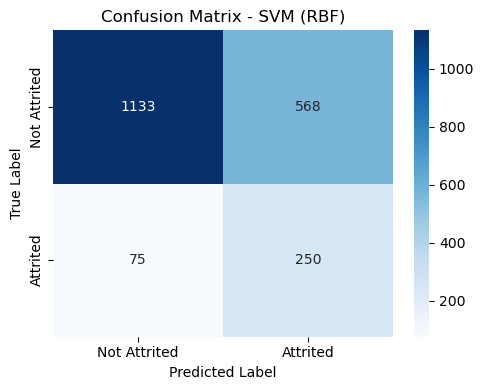

In [9]:
cm = confusion_matrix(y_test, svm_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Attrited", "Attrited"],
            yticklabels=["Not Attrited", "Attrited"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM (RBF)")
plt.tight_layout()
plt.show()


## Random Forest

In [10]:
import os, json, joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
# 确保引入了 pipeline 和 SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# 1. 组装 Random Forest 的防泄露流水线 (直接使用 OrdinalEncoder)
pipeline_rf = ImbPipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('smote', SMOTENC(categorical_features=cat_indices, random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', RandomForestClassifier(random_state=42, n_jobs=-1))
])

# 2. 网格搜索 (参数名加上 model__ 前缀)
param_grid_rf = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 5, 7]
}

grid_search_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid_rf, 
    cv=3, 
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

# 直接在未受污染的 X_train 上训练
print("开始训练 Random Forest (包含内部 SMOTE)...")
grid_search_rf.fit(X_train, y_train)

# 提取最佳模型
best_pipeline_rf = grid_search_rf.best_estimator_
print("===========Best Parameters from Grid Search (Random Forest)===========")
print("Best Parameters:", grid_search_rf.best_params_)
print(f"Best CV ROC-AUC: {grid_search_rf.best_score_:.4f}")

# 3. 预测 (在原始 X_test 上测试)
rf_pred = best_pipeline_rf.predict(X_test)
rf_prob = best_pipeline_rf.predict_proba(X_test)[:, 1]

# 安全处理 params 里的 Numpy 数据类型，防止 JSON 报错
safe_best_params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search_rf.best_params_.items()}




开始训练 Random Forest (包含内部 SMOTE)...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
===========Best Parameters from Grid Search (Random Forest)===========
Best Parameters: {'model__max_depth': 5, 'model__n_estimators': 500}
Best CV ROC-AUC: 0.8580


In [11]:
rf_metrics = {
    "model": "Random Forest",
    "best_params": safe_best_params,
    "best_cv_roc_auc": float(grid_search_rf.best_score_),
    "accuracy": float(accuracy_score(y_test, rf_pred)),
    "precision": float(precision_score(y_test, rf_pred, zero_division=0)),
    "recall": float(recall_score(y_test, rf_pred, zero_division=0)),
    "f1": float(f1_score(y_test, rf_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, rf_prob)),
    "confusion_matrix": confusion_matrix(y_test, rf_pred).tolist(),
}

print("\nConfusion Matrix:\n", confusion_matrix(y_test, rf_pred))
print("\nClassification Report:\n", classification_report(y_test, rf_pred, target_names=["Not Attrited", "Attrited"], digits=4))

# 5. 组装 Grid Search 详细结果供前端展示
results_df = pd.DataFrame(grid_search_rf.cv_results_)[
    ["param_model__n_estimators", "param_model__max_depth", "mean_test_score"]
].copy()
results_df.columns = ["N_Estimators", "Max_Depth", "ROC-AUC"]

grid_results = {
    "best_params": safe_best_params,
    "best_score": float(grid_search_rf.best_score_),
    "all_results": json.loads(results_df.to_json(orient="records"))
}

# 6. 创建文件夹并保存最终文件
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# 核心：保存完整的 pipeline 和 features 列表，不再单独保存 scaler！
joblib.dump({"pipeline": best_pipeline_rf, "features": top_10_features}, "models/rf_model.joblib")

# 保存 JSON 文件
with open("artifacts/rf_metrics.json", "w", encoding="utf-8") as f:
    json.dump(rf_metrics, f, indent=2)

with open("artifacts/rf_grid_results.json", "w", encoding="utf-8") as f:
    json.dump(grid_results, f, indent=2)

print("\nSaved: models/rf_model.joblib, artifacts/rf_metrics.json, artifacts/rf_grid_results.json")


Confusion Matrix:
 [[1080  621]
 [  43  282]]

Classification Report:
               precision    recall  f1-score   support

Not Attrited     0.9617    0.6349    0.7649      1701
    Attrited     0.3123    0.8677    0.4593       325

    accuracy                         0.6723      2026
   macro avg     0.6370    0.7513    0.6121      2026
weighted avg     0.8575    0.6723    0.7159      2026




Saved: models/rf_model.joblib, artifacts/rf_metrics.json, artifacts/rf_grid_results.json


## Naive Bayes

In [12]:
import os, json, joblib
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
# 确保引入了你之前定义的 pipeline 组件
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

# 1. 组装 Naive Bayes 的防泄露流水线
pipeline_nb = ImbPipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('smote', SMOTENC(categorical_features=cat_indices, random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', GaussianNB())
])

# 2. 网格搜索 (加入 var_smoothing 平滑参数以寻找最佳分布)
grid_para_nb = {
    "model__var_smoothing": np.logspace(0, -9, num=10) # 搜索 1e-0 到 1e-09
}

grid_search_nb = GridSearchCV(
    estimator=pipeline_nb, 
    param_grid=grid_para_nb, 
    cv=5, 
    scoring="roc_auc", 
    n_jobs=-1, 
    verbose=1
)

# 直接在原始 X_train 上训练 (Pipeline 内部会自动处理 SMOTE 和预处理)
grid_search_nb.fit(X_train, y_train)

# 提取最佳流水线
best_pipeline_nb = grid_search_nb.best_estimator_
print("===========Best Parameters from Grid Search (NB)===========")
print("Best Parameters:", grid_search_nb.best_params_)
print(f"Best CV ROC-AUC: {grid_search_nb.best_score_:.4f}")

# 3. 预测 (在原始 X_test 上测试)
nb_pred = best_pipeline_nb.predict(X_test)
nb_prob = best_pipeline_nb.predict_proba(X_test)[:, 1]

# 安全处理 params 里的 Numpy 数据类型，防止 JSON 报错
safe_best_params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search_nb.best_params_.items()}

# 4. 组装评估指标 (保持和 XGBoost 完全一致的结构)
nb_metrics = {
    "model": "Naive Bayes",
    "best_params": safe_best_params,
    "best_cv_roc_auc": float(grid_search_nb.best_score_),
    "accuracy": float(accuracy_score(y_test, nb_pred)),
    "precision": float(precision_score(y_test, nb_pred, zero_division=0)),
    "recall": float(recall_score(y_test, nb_pred, zero_division=0)),
    "f1": float(f1_score(y_test, nb_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, nb_prob)),
    "confusion_matrix": confusion_matrix(y_test, nb_pred).tolist()
}

print("\nConfusion Matrix:\n", confusion_matrix(y_test, nb_pred))
print("\nClassification Report:\n", classification_report(y_test, nb_pred, target_names=["Not Attrited", "Attrited"], digits=4))

# 5. 组装 Grid Search 详细结果供前端展示
results_df = pd.DataFrame(grid_search_nb.cv_results_)[["param_model__var_smoothing", "mean_test_score"]].copy()
results_df.columns = ["Var_Smoothing", "ROC-AUC"]

grid_results = {
    "best_params": safe_best_params,
    "best_score": float(grid_search_nb.best_score_),
    "all_results": json.loads(results_df.to_json(orient="records"))
}

# 6. 创建文件夹并保存最终文件
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

# 核心：保存完整的 pipeline 和 features 列表！
joblib.dump({"pipeline": best_pipeline_nb, "features": top_10_features}, "models/nb_model.joblib")

with open("artifacts/nb_metrics.json", "w", encoding="utf-8") as f:
    json.dump(nb_metrics, f, indent=2)

with open("artifacts/nb_grid_results.json", "w", encoding="utf-8") as f:
    json.dump(grid_results, f, indent=2)

print("\nSaved: models/nb_model.joblib, artifacts/nb_metrics.json, artifacts/nb_grid_results.json")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
===========Best Parameters from Grid Search (NB)===========
Best Parameters: {'model__var_smoothing': np.float64(1.0)}
Best CV ROC-AUC: 0.7402

Confusion Matrix:
 [[ 378 1323]
 [  21  304]]

Classification Report:
               precision    recall  f1-score   support

Not Attrited     0.9474    0.2222    0.3600      1701
    Attrited     0.1868    0.9354    0.3115       325

    accuracy                         0.3366      2026
   macro avg     0.5671    0.5788    0.3357      2026
weighted avg     0.8254    0.3366    0.3522      2026


Saved: models/nb_model.joblib, artifacts/nb_metrics.json, artifacts/nb_grid_results.json


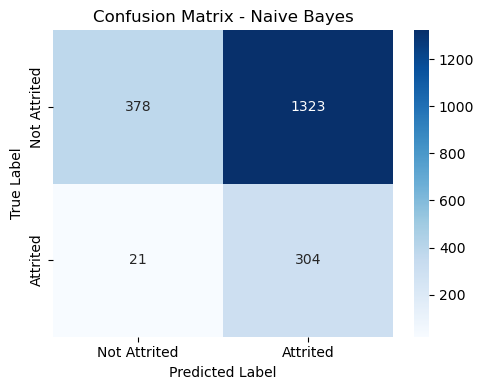

In [13]:
cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Attrited", "Attrited"],
            yticklabels=["Not Attrited", "Attrited"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Naive Bayes")
plt.tight_layout()
plt.show()


## XGBoost


In [ ]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, joblib


cat_indices = [X_train.columns.get_loc(col) for col in cat_cols]

# ==================== 2. 构建Pipeline ====================
pipeline_xgb = ImbPipeline([
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
    ('smote', SMOTENC(categorical_features=cat_indices, random_state=42)),
    ('scaler', MinMaxScaler()),
    ('model', XGBClassifier(
        random_state=42, 
        eval_metric='logloss',
        n_jobs=-1,
        # ⚠️ 重要：不要设置 scale_pos_weight，因为已经用了 SMOTE
    ))
])

# ==================== 3. 网格搜索 ====================
grid_para_xgb = {
    "model__n_estimators": [100, 300, 500],
    "model__max_depth": [3, 5, 7],
    "model__learning_rate": [0.01, 0.05, 0.1]  # 添加了 0.05
}

grid_search = GridSearchCV(
    estimator=pipeline_xgb, 
    param_grid=grid_para_xgb, 
    cv=3, 
    scoring="roc_auc", 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('encoder',
                                        OrdinalEncoder(handle_unknown='use_encoded_value',
                                                       unknown_value=-1)),
                                       ('smote',
                                        SMOTENC(categorical_features=[1, 3, 4,
                                                                      5, 6],
                                                random_state=42)),
                                       ('scaler', MinMaxScaler()),
                                       ('model',
                                        XGBClassifier(base_score=None,
                                                      booster=None,
                                                      callbacks=None,
                                                      colsample_bylevel=None,
                                                      colsample_bynode=None,
                                                      colsample_bytree=Non...
                                                      max_cat_to_onehot=None,
                                                      max_delta_step=None,
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=-1,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.01, 0.05, 0.1],
                         'model__max_depth': [3, 5, 7],
                         'model__n_estimators': [100, 300, 500]},
             scoring='roc_auc', verbose=1)

===========最佳参数===========
{'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}

Confusion Matrix:
 [[1104  597]
 [  45  280]]

Classification Report:
               precision    recall  f1-score   support

Not Attrited     0.9608    0.6490    0.7747      1701
    Attrited     0.3193    0.8615    0.4659       325

    accuracy                         0.6831      2026
   macro avg     0.6401    0.7553    0.6203      2026
weighted avg     0.8579    0.6831    0.7252      2026



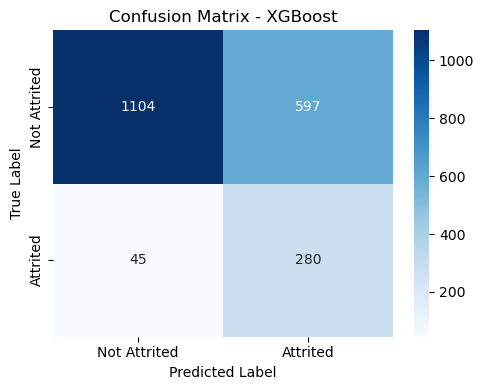

In [22]:
# 提取最佳模型
best_pipeline_xgb = grid_search.best_estimator_
print("===========最佳参数===========")
print(grid_search.best_params_)

# ================= 补充这几行预测代码 =================
# 1. 使用最佳模型在测试集上预测
xgb_pred = best_pipeline_xgb.predict(X_test)
xgb_prob = best_pipeline_xgb.predict_proba(X_test)[:, 1]

# 2. 安全处理 params 里的 Numpy 数据类型，防止后面存 JSON 报错
safe_best_params = {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search.best_params_.items()}
# ======================================================

# 接下来再运行你的评估代码，就不会报错了
xgb_metrics = {
    "model": "XGBoost",
    "best_params": safe_best_params,
    "best_cv_roc_auc": float(grid_search.best_score_),
    "accuracy": float(accuracy_score(y_test, xgb_pred)),
    "precision": float(precision_score(y_test, xgb_pred, zero_division=0)),
    "recall": float(recall_score(y_test, xgb_pred, zero_division=0)),
    "f1": float(f1_score(y_test, xgb_pred, zero_division=0)),
    "roc_auc": float(roc_auc_score(y_test, xgb_prob)),
    "confusion_matrix": confusion_matrix(y_test, xgb_pred).tolist()
}

# ... 后面接着你原来的 print 和画图代码
print("\nConfusion Matrix:\n", confusion_matrix(y_test, xgb_pred))
print("\nClassification Report:\n", classification_report(y_test, xgb_pred, target_names=["Not Attrited", "Attrited"], digits=4))


plt.figure(figsize=(5,4))
sns.heatmap(xgb_metrics["confusion_matrix"], annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Attrited", "Attrited"],
            yticklabels=["Not Attrited", "Attrited"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - XGBoost")
plt.tight_layout()
plt.show()

## ROC Comparison

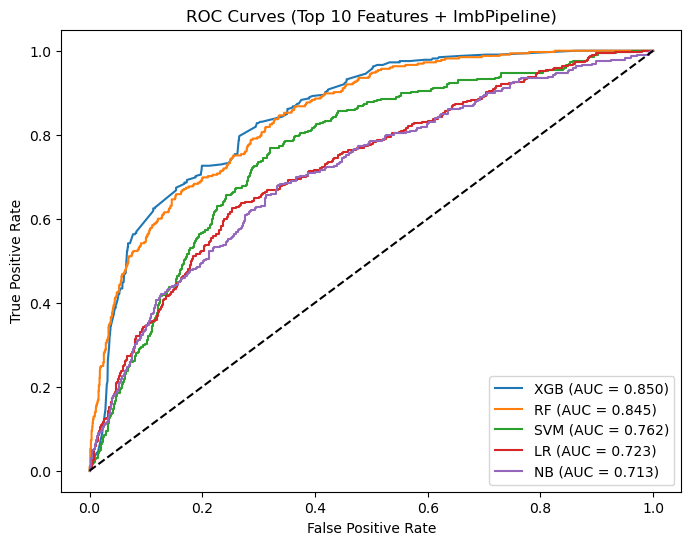

✅ 最新的 ROC 曲线数据已更新！前端图表已同步！


In [23]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import json

roc_pack = {}
# 把你刚刚训练好的 5 个 best_pipeline 收集起来
models_dict = {
    "XGB": best_pipeline_xgb,
    "RF": best_pipeline_rf,
    "SVM": best_pipeline_svm,
    "LR": best_pipeline_lr,
    "NB": best_pipeline_nb
}

plt.figure(figsize=(8,6))
for name, pipeline in models_dict.items():
    # 直接用 pipeline 预测概率
    prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_score = roc_auc_score(y_test, prob)
    
    roc_pack[name] = {"fpr": fpr.tolist(), "tpr": tpr.tolist(), "auc": float(auc_score)}
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Top 10 Features + ImbPipeline)')
plt.legend()
plt.show()

# 覆盖掉旧文件
with open("artifacts/roc_all_models.json", "w") as f:
    json.dump(roc_pack, f, indent=2)
print("✅ 最新的 ROC 曲线数据已更新！前端图表已同步！")

In [19]:
df.shape

(10127, 24)